# Import package

In [131]:
import matplotlib.pyplot as plt
from C_SingleHighQ import SingleHighQ


# import data

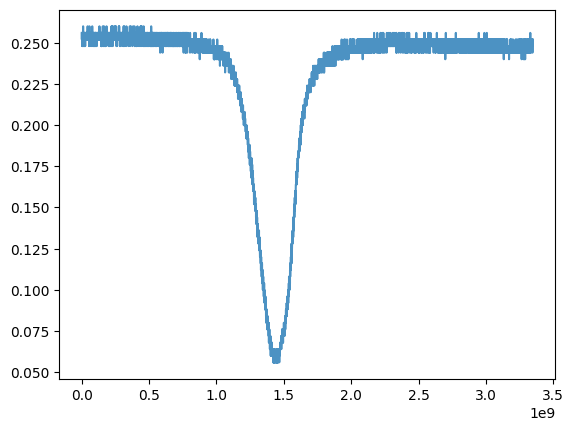

In [132]:
measure_method = 'FuncGenOsci'


### another example usage for Fine Scan measurement
Q = SingleHighQ()
Fig_T = plt.figure()
ax_T = Fig_T.add_subplot(111)
if measure_method == 'FineScan':
    # T_corrected = Q.load_data_singleQ(file_name=r'C:\Users\yijun.yang\OneDrive\1A_PostDoc\SiN\202509_2509SiN700A_Multipassage\mesurement\Laser fine tunning\D80\RR0.4.txt',
    #                                   model='FineScan',
    #                                   )
    FolderName = r'C:\Users\yijun.yang\OneDrive\1A_PostDoc\SiN\202511SiN700A_4P_HighQ-PC\FineScan Measurement\D80'
    FolderName = r'/Users/yangyijun/Library/CloudStorage/OneDrive-Personal/1A_PostDoc/SiN/202511SiN700A_4P_HighQ-PC/FineScan Measurement/D75'
    FolderName = r'C:\Users\yijun.yang\OneDrive\1A_PostDoc\SiN\202511SiN700A_4P_HighQ-PC\FineScan Measurement\EdgeCoupler\D85'
    # FolderName = r'/Users/yangyijun/Library/CloudStorage/OneDrive-Personal/1A_PostDoc/SiN/202511SiN700A_4P_HighQ-PC/FineScan Measurement/EdgeCoupler/D85'
    # FolderName = ''

    FileName = r'RRW1.1G0.5L1522.856F10mHzA2V.txt'
    # RRW1.1G0.5L1570.515F510mHzA2V
    from F_GetConfig import F_GetConfig
    config = F_GetConfig(FileName = FileName)
    ScanConfig = {'Vpp_V':config['amplitude_V']*2,'Freq_Hz':config['freq_mHz']*1e-3,'Tunning_Hz_V':300*1e6}
    # ScanConfig = {'Vpp_V':config['amplitude_V']*2,'Freq_Hz':10*1e-3,'Tunning_Hz_V':300*1e6}
    from os.path import join
    file_name=join(FolderName,FileName)
    T_corrected = Q.load_data_singleQ(file_name=file_name,
                                        model='FineScan',ScanParams=ScanConfig)

elif measure_method == 'FuncGenOsci':
    ### measurment from Osci###

    # config = {'wavelength_nm':1548}
    import os
    from F_load_FuncGenOsci import F_load_FuncGenOsci
    from F_GetConfig import F_GetConfig_FuncGenOsci
    SampleDevice = 'R100W1.1G500_1548nm'
    SampleDevice = 'R100W1.1G500_1510.6nm'
    SampleDevice = 'R70W2.8G600_1626.383nm'
    SampleDevice = 'R100W1.1G500_1520.5nm'
    SampleDevice = 'R100W1.1G500_1529.0nm'
    SampleDevice = 'R100W1.1G500_1541.0nm'
    SampleDevice = 'R100W1.1G500_1560.3nm'
    SampleDevice = 'R100W1.1G500_1569.2nm'
    SampleDevice = 'R100W1.1G500_1580.0nm'
    SampleDevice = 'R100W1.1G500_1591.0nm'
    SampleDevice = 'R100W1.1G500_1598.3nm'
    ###
    SampleDevice = 'R114W1.1G600_1549.965nm'
    SampleDevice = 'R114W1.1G600_1505.210nm'
    SampleDevice = 'R114W1.1G600_1568.684nm'
    SampleDevice = 'R114W1.1G600_1505.210nm'
    SampleDevice = 'R114W1.1G600_1509.489nm'
    
    SampleDevice = 'R114W1.1G600_1600.500nm'
    
    config = F_GetConfig_FuncGenOsci(FileName=SampleDevice)
    ParentFolder  = '/Users/yangyijun/Library/CloudStorage/OneDrive-Personal/1A_PostDoc/SiN/202511SiN700A_4P_HighQ-PC/measure_FuncGenOsci'
    ParentFolder = '/Users/yangyijun/Library/CloudStorage/OneDrive-Personal/1A_PostDoc/SiN/2602SiN700A_9UVTrench_25x25/MesFuncGenOsci_2602SiN700A_15C-29mT'
    ParentFolder = '/Users/yangyijun/Library/CloudStorage/OneDrive-Personal/1A_PostDoc/SiN/2602SiN700A_9UVTrench_25x25/MesFuncGenOsci_2602SiN700A_15C-29mT-CHF70'
    ParentFolder = '/Users/yangyijun/Library/CloudStorage/OneDrive-Personal/1A_PostDoc/SiN/2602SiN700A_9UVTrench_25x25/MesFuncGenOsci_2602SiN700A_15C-29mT-CHF65'

    # ParentFolder = '/Users/yangyijun/Library/CloudStorage/OneDrive-Personal/1A_PostDoc/SiN/2602SiN700A_9UVTrench_25x25/MesFuncGenOsci_2602SiN700A_25C-29mT'
    FolderName = os.path.join(ParentFolder, SampleDevice)
    file_fg = 'c1_functiongenerator_TDS5104BCH1_volts.txt'
    file_res = 'c2_resonance_TDS5104BCH2_volts.txt'
    file_name_fg = os.path.join(FolderName, file_fg)
    file_name_res = os.path.join(FolderName, file_res)
    T_corrected = F_load_FuncGenOsci(file_name_fg=file_name_fg, 
                            file_name_res=file_name_res, 
                        #    ax=ax
                            )
    # add an offset to T_corrected['nu_Hz'] so that it is always positive
    T_corrected['nu_Hz'] = T_corrected['nu_Hz'] - T_corrected['nu_Hz'].min() + 1
ax_T.plot(T_corrected['nu_Hz'], T_corrected['T_linear'],label='resonance',alpha=0.8)






# Singlet fit


FIT QUALITY REPORT - Single Lorentzian

Overall Fit Quality: Fair
Suitable for Analysis: NO

------------------------------------------------------------
Goodness-of-Fit Metrics:
------------------------------------------------------------
  R² (coefficient of determination): 0.977378
  Adjusted R²:                        0.977373
  RMSE (Root Mean Square Error):      2.787303e-02
  Normalized RMSE:                    3.463%
  χ² (Chi-squared):                   7.769056e+00
  Reduced χ²:                         0.000777
  Residual Std Dev:                   2.501316e-02
  Max Absolute Residual:              1.167106e-01

------------------------------------------------------------
Fitted Parameters:
------------------------------------------------------------
  Amplitude       = 8.274318e-01 ± 1.633580e-03 (0.20%)
  FWHM (Hz)       = -2.483339e+08 ± 6.938271e+05 (0.28%)
  Resonance (Hz)  = 1.437385e+09 ± 2.450941e+05 (0.02%)

----------------------------------------------------------

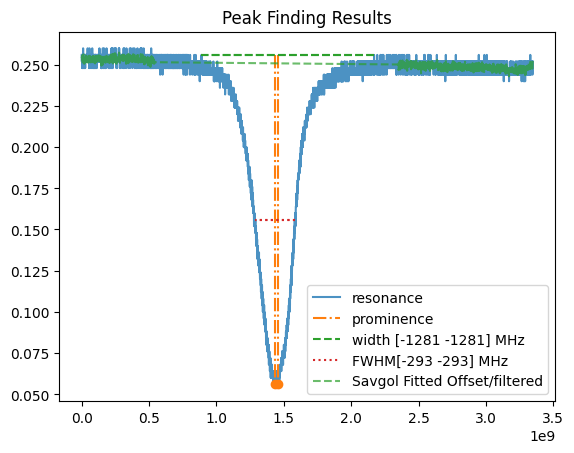

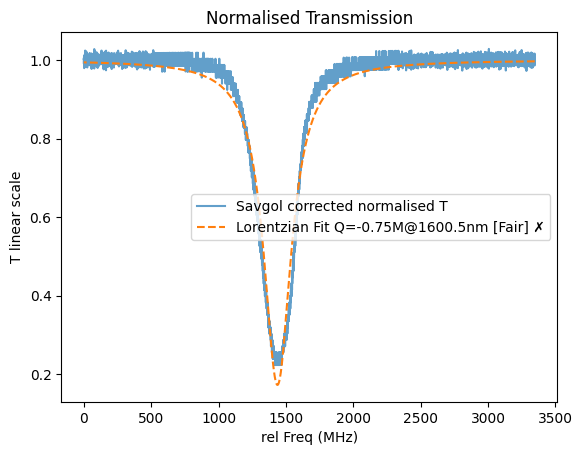

In [133]:
Fig_T_normalised = plt.figure()
ax_T_normalised = Fig_T_normalised.add_subplot(111)

param_find_peaks = {'distance':400,# in number of points
                    'prominence':0.0001,# need to be adjusted according to the actual data
                    'width':5,# in number of points
                    'rel_height':1,# don't change this one
                    }
param_rel = {'Rel_FWHM':0.2,
                'Rel_A':0.2,
                'Rel_Peak':0.2,
                'factor_remove_points':1.1,# factor to multiply the width to get the points to remove for Savgol filtering
    }

param_find_peaks = {'distance':50,# in number of points
                    'prominence':0.1,# need to be adjusted according to the actual data
                    'width':50,# in number of points
                    'rel_height':1,# don't change this one
                    }
param_rel = {'Rel_FWHM':0.2,
             'Rel_A':0.2,
             'Rel_Peak':0.2,
             'factor_remove_points':1.4,# [0.5,7] factor to multiply the width to get the points to remove for Savgol filtering
    }

from F_FindPeaks import F_SelectPeaks
# param_find_peaks = F_SelectPeaks(T_corrected['T_linear'].values, param_find_peaks, num_peaks=5)
T_normalised = Q.PL_FitResonance(
    T_corrected=T_corrected,
    center_wl_nm=config['wavelength_nm'],
    ax_T_normalised=ax_T_normalised,
    ax_T=ax_T,
    param_rel=param_rel,
    **param_find_peaks)

# plt.show()
# plt.figure(Fig_T.number)
# plt.show()

# Fig_T.canvas.draw_idle()
display(Fig_T)            # shows updated ax_T
# display(Fig_T_normalised)

# save image

In [134]:
# save all the figure
Fig_T.savefig(os.path.join(FolderName, 'Figure_T.png'), dpi=300)
Fig_T_normalised.savefig(os.path.join(FolderName, 'Figure_T_normalised.png'), dpi=300)

# Doublet fit


FIT QUALITY REPORT - Double Lorentzian

Overall Fit Quality: Fair
Suitable for Analysis: NO

------------------------------------------------------------
Goodness-of-Fit Metrics:
------------------------------------------------------------
  R² (coefficient of determination): 0.977155
  Adjusted R²:                        0.977144
  RMSE (Root Mean Square Error):      2.800961e-02
  Normalized RMSE:                    3.480%
  χ² (Chi-squared):                   7.845382e+00
  Reduced χ²:                         0.000785
  Residual Std Dev:                   2.513539e-02
  Max Absolute Residual:              1.249612e-01

------------------------------------------------------------
Fitted Parameters:
------------------------------------------------------------
  Amplitude       = 8.269714e-01 ± 1.642091e-03 (0.20%)
  FWHM (Hz)       = -2.485576e+08 ± 7.002248e+05 (0.28%)
  Resonance (Hz)  = 1.435198e+09 ± 2.466224e+05 (0.02%)

----------------------------------------------------------

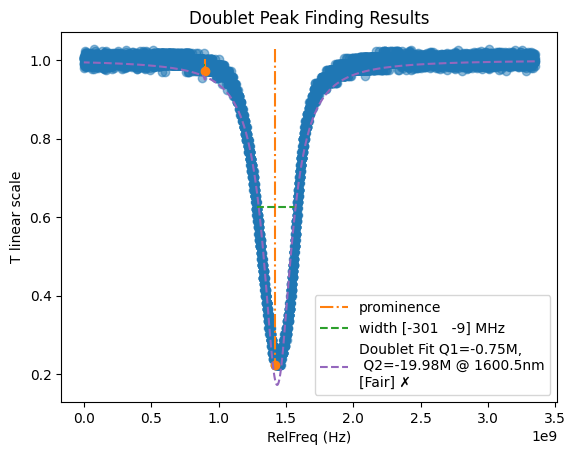

In [135]:
Fig_Doublet = plt.figure()
ax_Doublet = Fig_Doublet.add_subplot(111)
param_find_DoubletResonance = {'distance':50,
                            'prominence':0.03,# can change
                            'width':15,# can change
                            'rel_height':0.5,
                            } # don't add random stuff here, only the parameters suitable for scipy.find_peaks

param_rel_Doublet = {'Rel_A1':0.99,
                        'Rel_A2':0.99,
                    #  'Rel_FWHM1':0.8,
                    #  'Rel_FWHM2':0.8,
                        'Rel_Peak1': 0.01,
                        'Rel_Peak2':0.01,
                        '1st peak':0, # multiple peaks found, choose which the one as the first peak
                        '2nd peak':1,}# multiple peaks found, choose which the one as the second peak

opt_Doublet, pcov_Doublet, f_func_DoubleLorentzian = Q.Q_FitDoubletResonance(
    T_normalised,
    center_wl_nm=config['wavelength_nm'],
    param_find_DoubletResonance=param_find_DoubletResonance,
    param_rel_Doublet=param_rel_Doublet,
    ax_Doublet=ax_Doublet
    )




plt.show()

# Save all the figure

In [136]:
# # save all the figure
# Fig_T.savefig(os.path.join(FolderName, 'Figure_T.png'), dpi=300)
# Fig_T_normalised.savefig(os.path.join(FolderName, 'Figure_T_normalised.png'), dpi=300)
Fig_Doublet.savefig(os.path.join(FolderName, 'Figure_Doublet.png'), dpi=300)